## Linear baseline methods: tropical SST drivers of the SH-EDJ

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from eofs.xarray import Eof
from sklearn.cluster import KMeans

from support_functions_0926 import (
    # preprocessing
    lat_band, to_360, djf_mean, on_mean, wmean, standardize, standardize_onestd,
    standardize_train_test,
    # regression, MCA, composites
    cv_regression, sign_agreement, mca, mca_folds, match_to_full, composite_sig,
    # plotting
    cyclic, _circular_boundary, plot_coef_maps, plot_mca, plot_mca_stippled,
    plot_coefficient_correlations, plot_cluster_composites, plot_composite_pair,
)

In [2]:
filepath_results = 'results_linear/'
#filepath = 'training/'
datapath='../data/cesm2/'

## Background

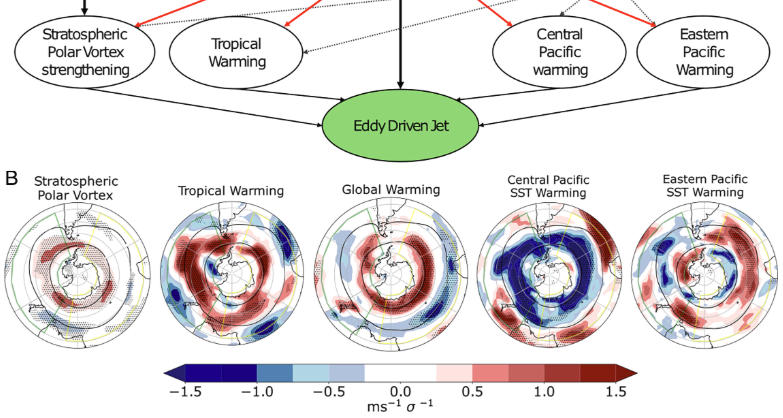

Summary of Metrics used in Mindlin et al 2025:
- TW, evaluated as the zonal average of temperature at 200 hPa between 15S and 15N in DJF
- SPV strength in October–November, evaluated as the zonal mean of the zonal wind strength at 50 hPa between 50S and 60S
- The central Pacific (CP) and eastern Pacific (EP) sea surface temperature in DJF, evaluated as the sea surface temperature averaged over the boxes [5N5S,180-250E] and [0-10S,260-280E] respectively in DJF and
- Global mean surface temperature (GW), the area weighted global average of surface air temperature in DJF.

Saggioro 2024:

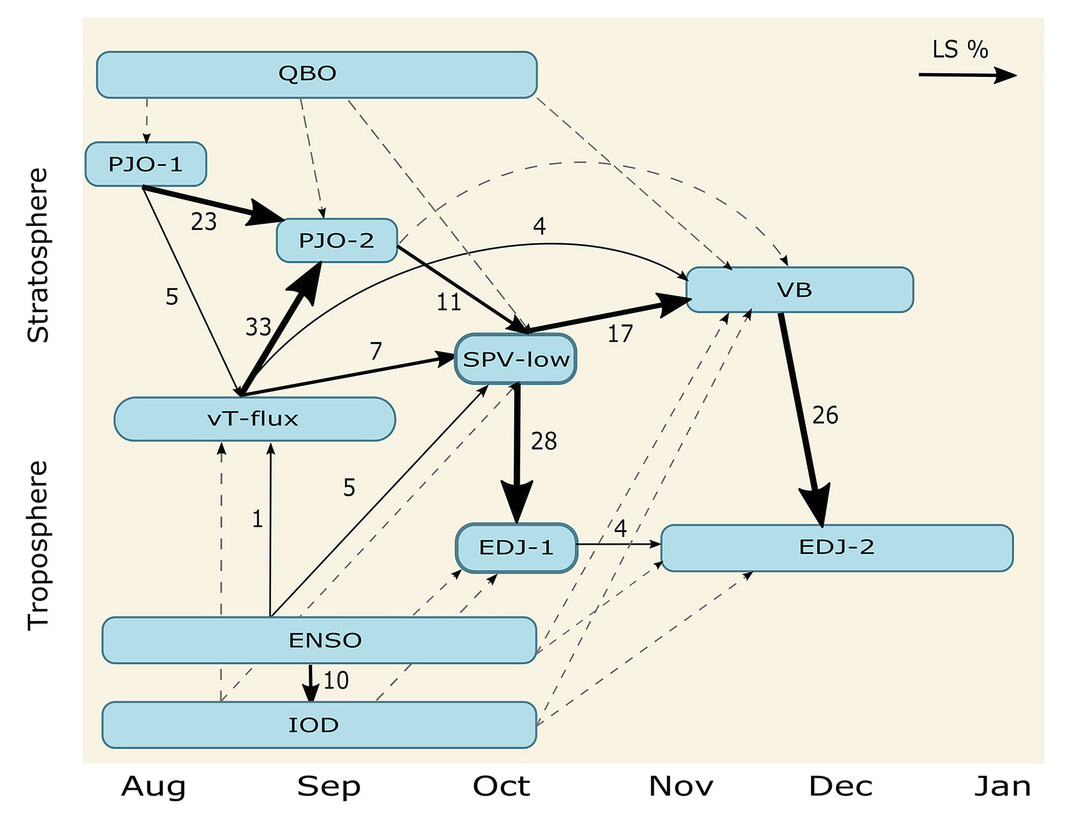

## Data import and pre-processing

In [3]:
# Load data
ds_ts    = xr.open_dataset(datapath + 'tos_Omon_CESM2_piControl_r1i1p1f1_gr.nc')
ds_ua50  = xr.open_dataset(datapath + 'ua50_Amon_CESM2_piControl_r1i1p1f1_gn.nc')
ds_ua850 = xr.open_dataset(datapath + 'ua850_Amon_CESM2_piControl_r1i1p1f1_gn.nc')

ts    = ds_ts['tos']
ua50  = ds_ua50['ua'].squeeze('plev', drop=True)
ua850 = ds_ua850['ua'].squeeze('plev', drop=True)

ts, ua50, ua850 = to_360(ts), to_360(ua50), to_360(ua850)

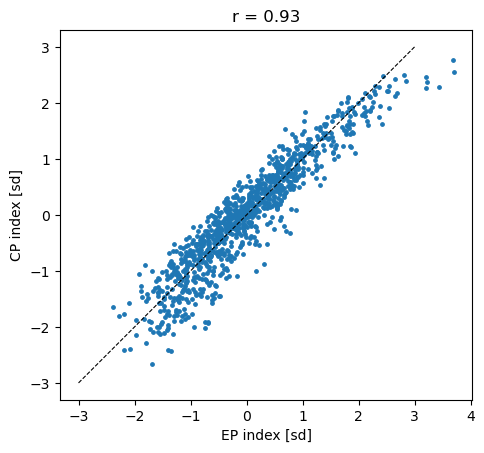

In [4]:
# Indices, standardised over the full record (used for the scatter plot and the composites)
spv = standardize(on_mean(wmean(lat_band(ua50, -65, -50))))
cp  = standardize(djf_mean(wmean(lat_band(ts, -5, 5).sel(lon=slice(180, 250)))))
ep  = standardize(djf_mean(wmean(lat_band(ts, -10, 0).sel(lon=slice(260, 280)))))

# Target: DJF ua850 anomalies divided by ONE std across all grid cells, to retain areas of high variability.
# NOTE: `target` is not used below — the cross-validated regression standardises target_raw
# per grid cell with training-block statistics (standardize_train_test).
target = standardize_onestd(djf_mean(lat_band(ua850, -65, -35)))

spv, cp, ep, target = xr.align(spv, cp, ep, target, join='inner')

plt.scatter(ep, cp, s=6)
plt.plot([-3, 3], [-3, 3], 'k--', lw=0.8)
plt.xlabel('EP index [sd]')
plt.ylabel('CP index [sd]')
plt.gca().set_aspect('equal')
plt.title(f'r = {np.corrcoef(ep, cp)[0, 1]:.2f}')
plt.show()

# Without standardisation (standardised with training statistics inside the cross-validation)
spv_raw    = on_mean(wmean(lat_band(ua50, -60, -50)))
cp_raw     = djf_mean(wmean(lat_band(ts, -5, 5).sel(lon=slice(180, 250))))
ep_raw     = djf_mean(wmean(lat_band(ts, -10, 0).sel(lon=slice(260, 280))))
target_raw = djf_mean(lat_band(ua850, -65, -35))

spv_raw, cp_raw, ep_raw, target_raw = xr.align(spv_raw, cp_raw, ep_raw, target_raw, join='inner')

Issue with collinearity: OLS estimator becomes unstable - coefficient estimates are still unbiased in theory, but their variance inflates dramatically meaning that small changes in the data can lead to large changes in the estimated coefficients which can make individual coefficients unreliable even if the overall model fit (R²) looks good

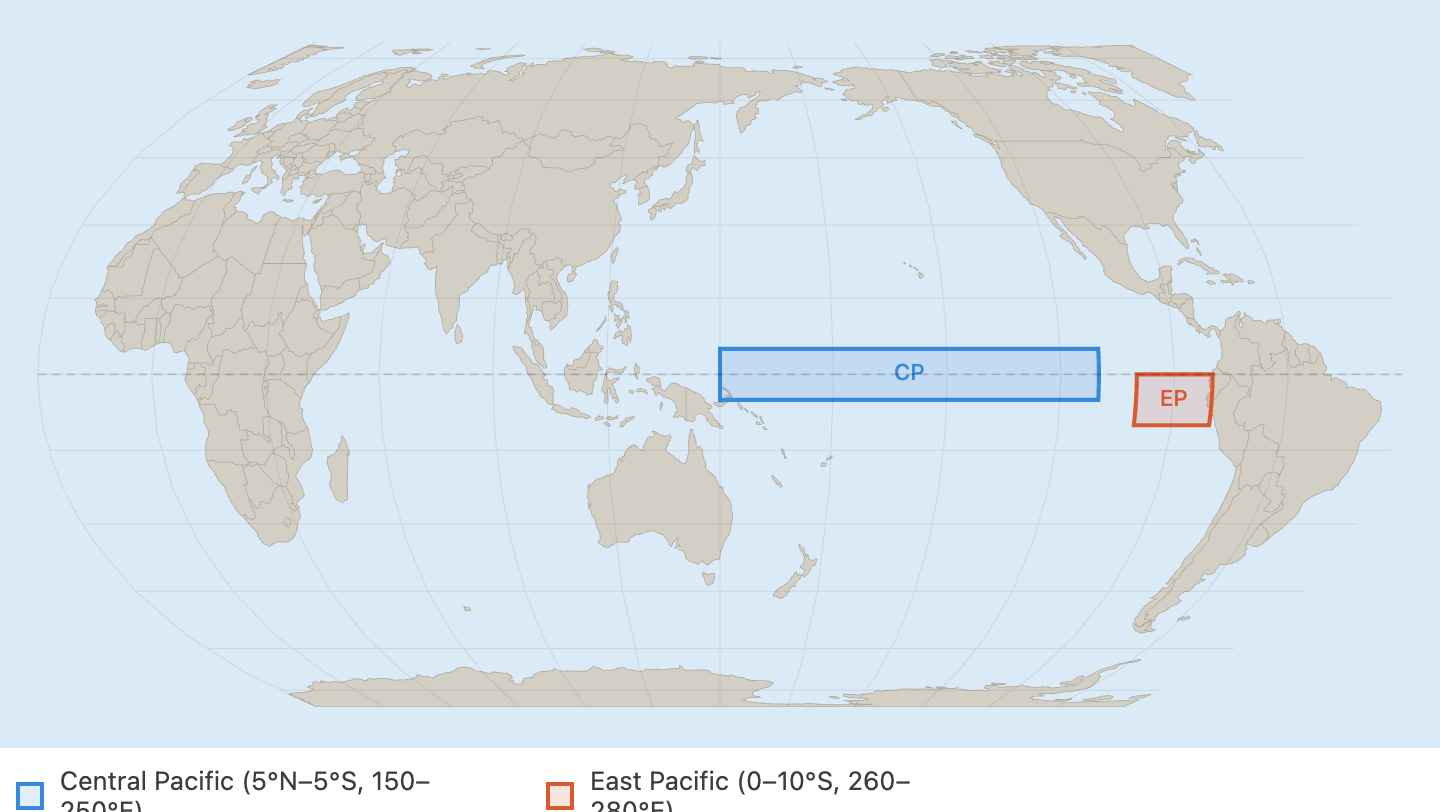

## Linear regression at each grid-cell using indices 

Fold 01/10 — train  100 yr, test  896 yr | ACC train +0.326 | test +0.277
Fold 02/10 — train  100 yr, test  893 yr | ACC train +0.367 | test +0.286
Fold 03/10 — train  100 yr, test  893 yr | ACC train +0.356 | test +0.297
Fold 04/10 — train  100 yr, test  893 yr | ACC train +0.371 | test +0.295
Fold 05/10 — train  100 yr, test  893 yr | ACC train +0.312 | test +0.289
Fold 06/10 — train  100 yr, test  893 yr | ACC train +0.370 | test +0.289
Fold 07/10 — train  100 yr, test  893 yr | ACC train +0.357 | test +0.296
Fold 08/10 — train  100 yr, test  893 yr | ACC train +0.359 | test +0.294
Fold 09/10 — train  100 yr, test  893 yr | ACC train +0.358 | test +0.289
Fold 10/10 — train   99 yr, test  897 yr | ACC train +0.355 | test +0.292

ACC (area-weighted, mean over folds): train +0.353 | test +0.290 ± 0.006


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/

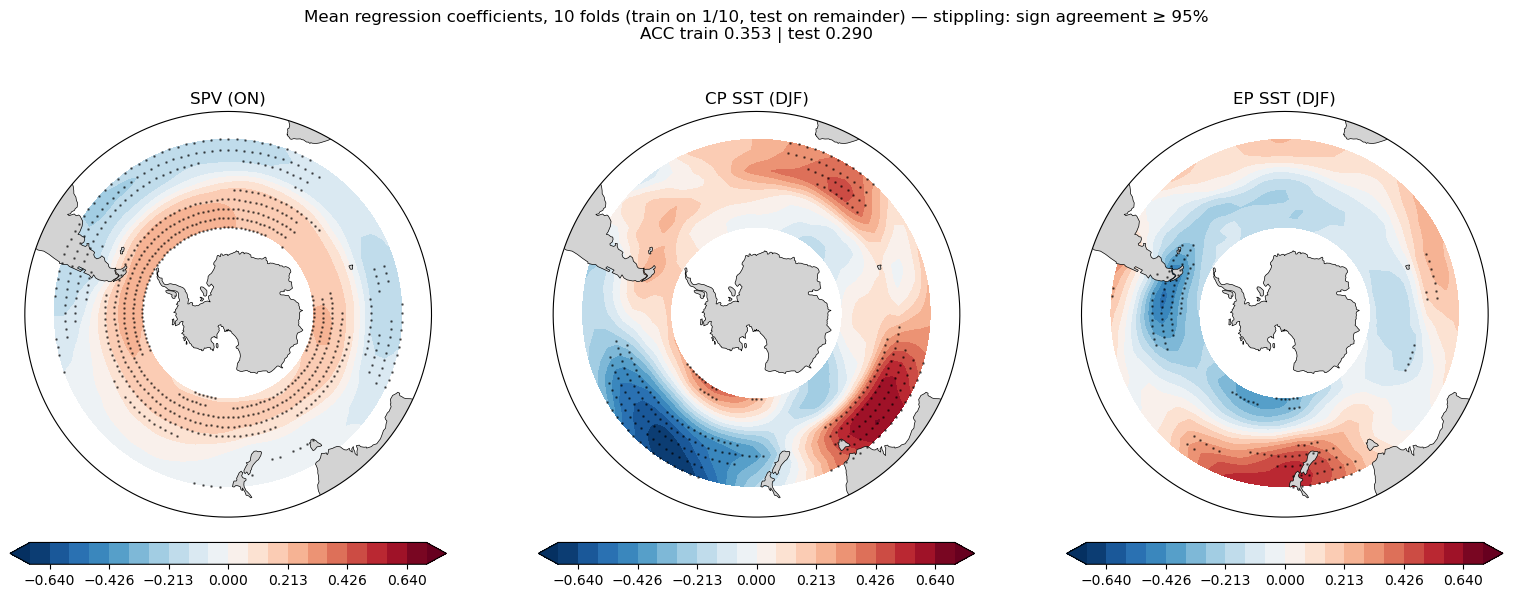

In [5]:
N_FOLDS    = 10
BUFFER     = 3          # seasons excluded either side of the train block
PRED_NAMES = ['SPV (ON)', 'CP SST (DJF)', 'EP SST (DJF)']
predictors = [spv_raw, cp_raw, ep_raw]

# train on ONE block of seasons, test on all others (minus the buffer)
years = target_raw['season_year'].values
cv = cv_regression(predictors, target_raw, years, n_folds=N_FOLDS, buffer=BUFFER)

mean_coefs = cv['coefs'].mean(0)                                   # (3, nlat, nlon)
stipple    = sign_agreement(cv['coefs'], ref=mean_coefs) >= 0.95   # with 10 folds: all 10 agree

plot_coef_maps(mean_coefs, stipple, target_raw['lat'], target_raw['lon'], PRED_NAMES,
               f'Mean regression coefficients, {N_FOLDS} folds '
               f'(train on 1/{N_FOLDS}, test on remainder) — stippling: sign agreement ≥ 95%\n'
               f'ACC train {np.mean(cv["acc_train"]):.3f} | test {np.mean(cv["acc_test"]):.3f}');

## PCA

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicat

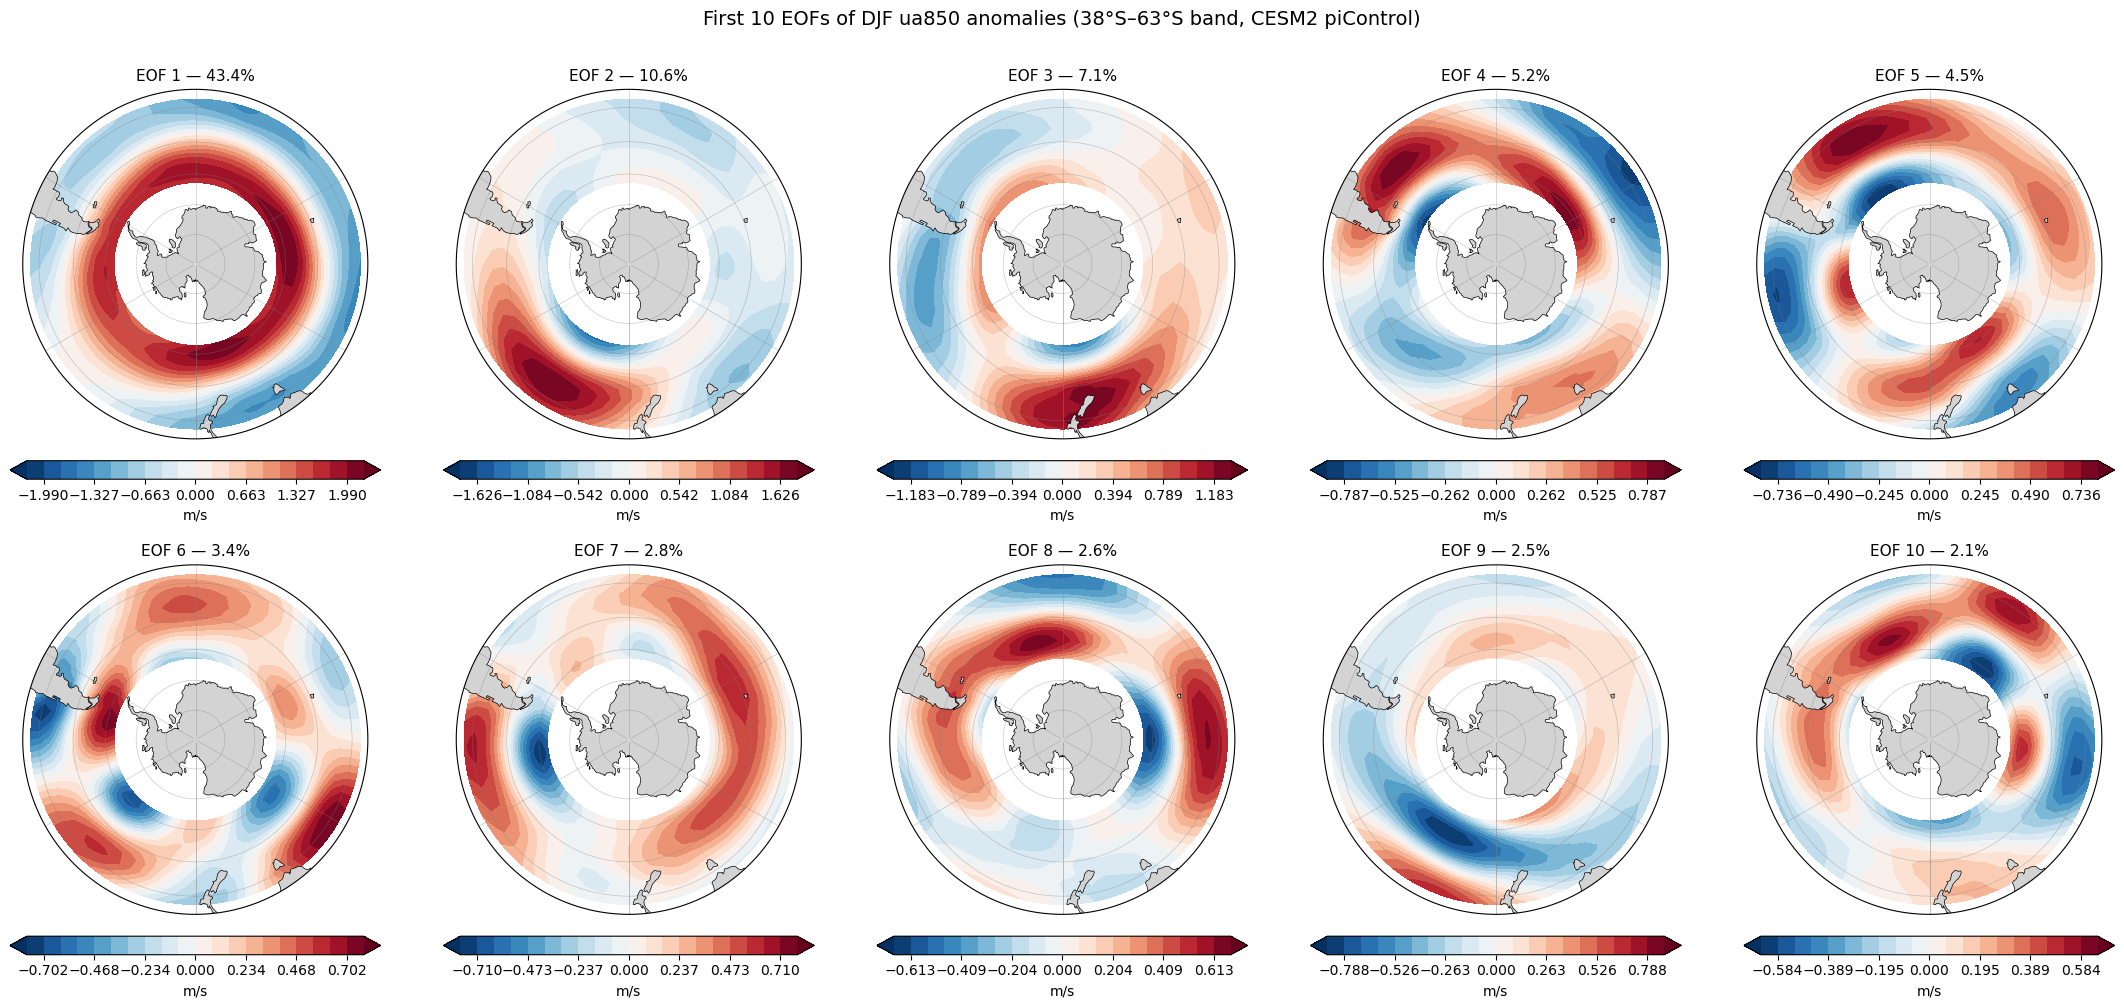

 mode   var %   cum %  North err
    1   43.36   43.36       1.94
    2   10.58   53.94       0.47
    3    7.10   61.04       0.32
    4    5.15   66.19       0.23
    5    4.51   70.71       0.20
    6    3.37   74.08       0.15
    7    2.80   76.88       0.13
    8    2.56   79.43       0.11
    9    2.46   81.89       0.11
   10    2.10   83.99       0.09


In [7]:
N_EOFS = 10

data = target_raw.rename({'season_year': 'time'})
data = data - data.mean('time')                    # anomalies; do NOT divide by std

weights = np.sqrt(np.cos(np.deg2rad(data['lat']))).broadcast_like(data.isel(time=0, drop=True))
solver  = Eof(data, weights=weights)

eofs = solver.eofsAsCovariance(neofs=N_EOFS)       # units of m/s
pcs  = solver.pcs(npcs=N_EOFS, pcscaling=1)        # unit variance
var  = solver.varianceFraction(neigs=N_EOFS)
err  = solver.northTest(neigs=N_EOFS, vfscaled=True)

fig, axes = plt.subplots(2, 5, figsize=(22, 10),
                         subplot_kw={'projection': ccrs.SouthPolarStereo()})

for i, ax in enumerate(axes.ravel()):
    e = eofs.isel(mode=i)
    vmax = float(np.abs(e).max())
    levels = np.linspace(-vmax, vmax, 21)
    d, lonc = cyclic(e.values, e['lon'].values)

    ax.set_extent([-180, 180, -90, -35], crs=ccrs.PlateCarree())
    _circular_boundary(ax)
    im = ax.contourf(lonc, e['lat'].values, d, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.gridlines(linewidth=0.4, color='gray', alpha=0.5)
    ax.set_title(f'EOF {i+1} — {float(var[i])*100:.1f}%', fontsize=11)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.85, label='m/s')

lat_s, lat_n = float(data['lat'].min()), float(data['lat'].max())
fig.suptitle(f'First {N_EOFS} EOFs of DJF ua850 anomalies '
             f'({abs(lat_n):.0f}°S–{abs(lat_s):.0f}°S band, CESM2 piControl)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

print(f"{'mode':>5} {'var %':>7} {'cum %':>7} {'North err':>10}")
for i in range(N_EOFS):
    print(f'{i+1:>5} {float(var[i])*100:>7.2f} {float(var[:i+1].sum())*100:>7.2f} '
          f'{float(err[i])*100:>10.2f}')

## MCA

SPV not regressed out - does not seem to make a big difference to the patterns

mode 1: SCF= 98.9%   r=+0.58
mode 2: SCF=  0.5%   r=+0.34
mode 3: SCF=  0.3%   r=+0.21
mode 4: SCF=  0.1%   r=+0.28
mode 5: SCF=  0.0%   r=+0.22


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/construc

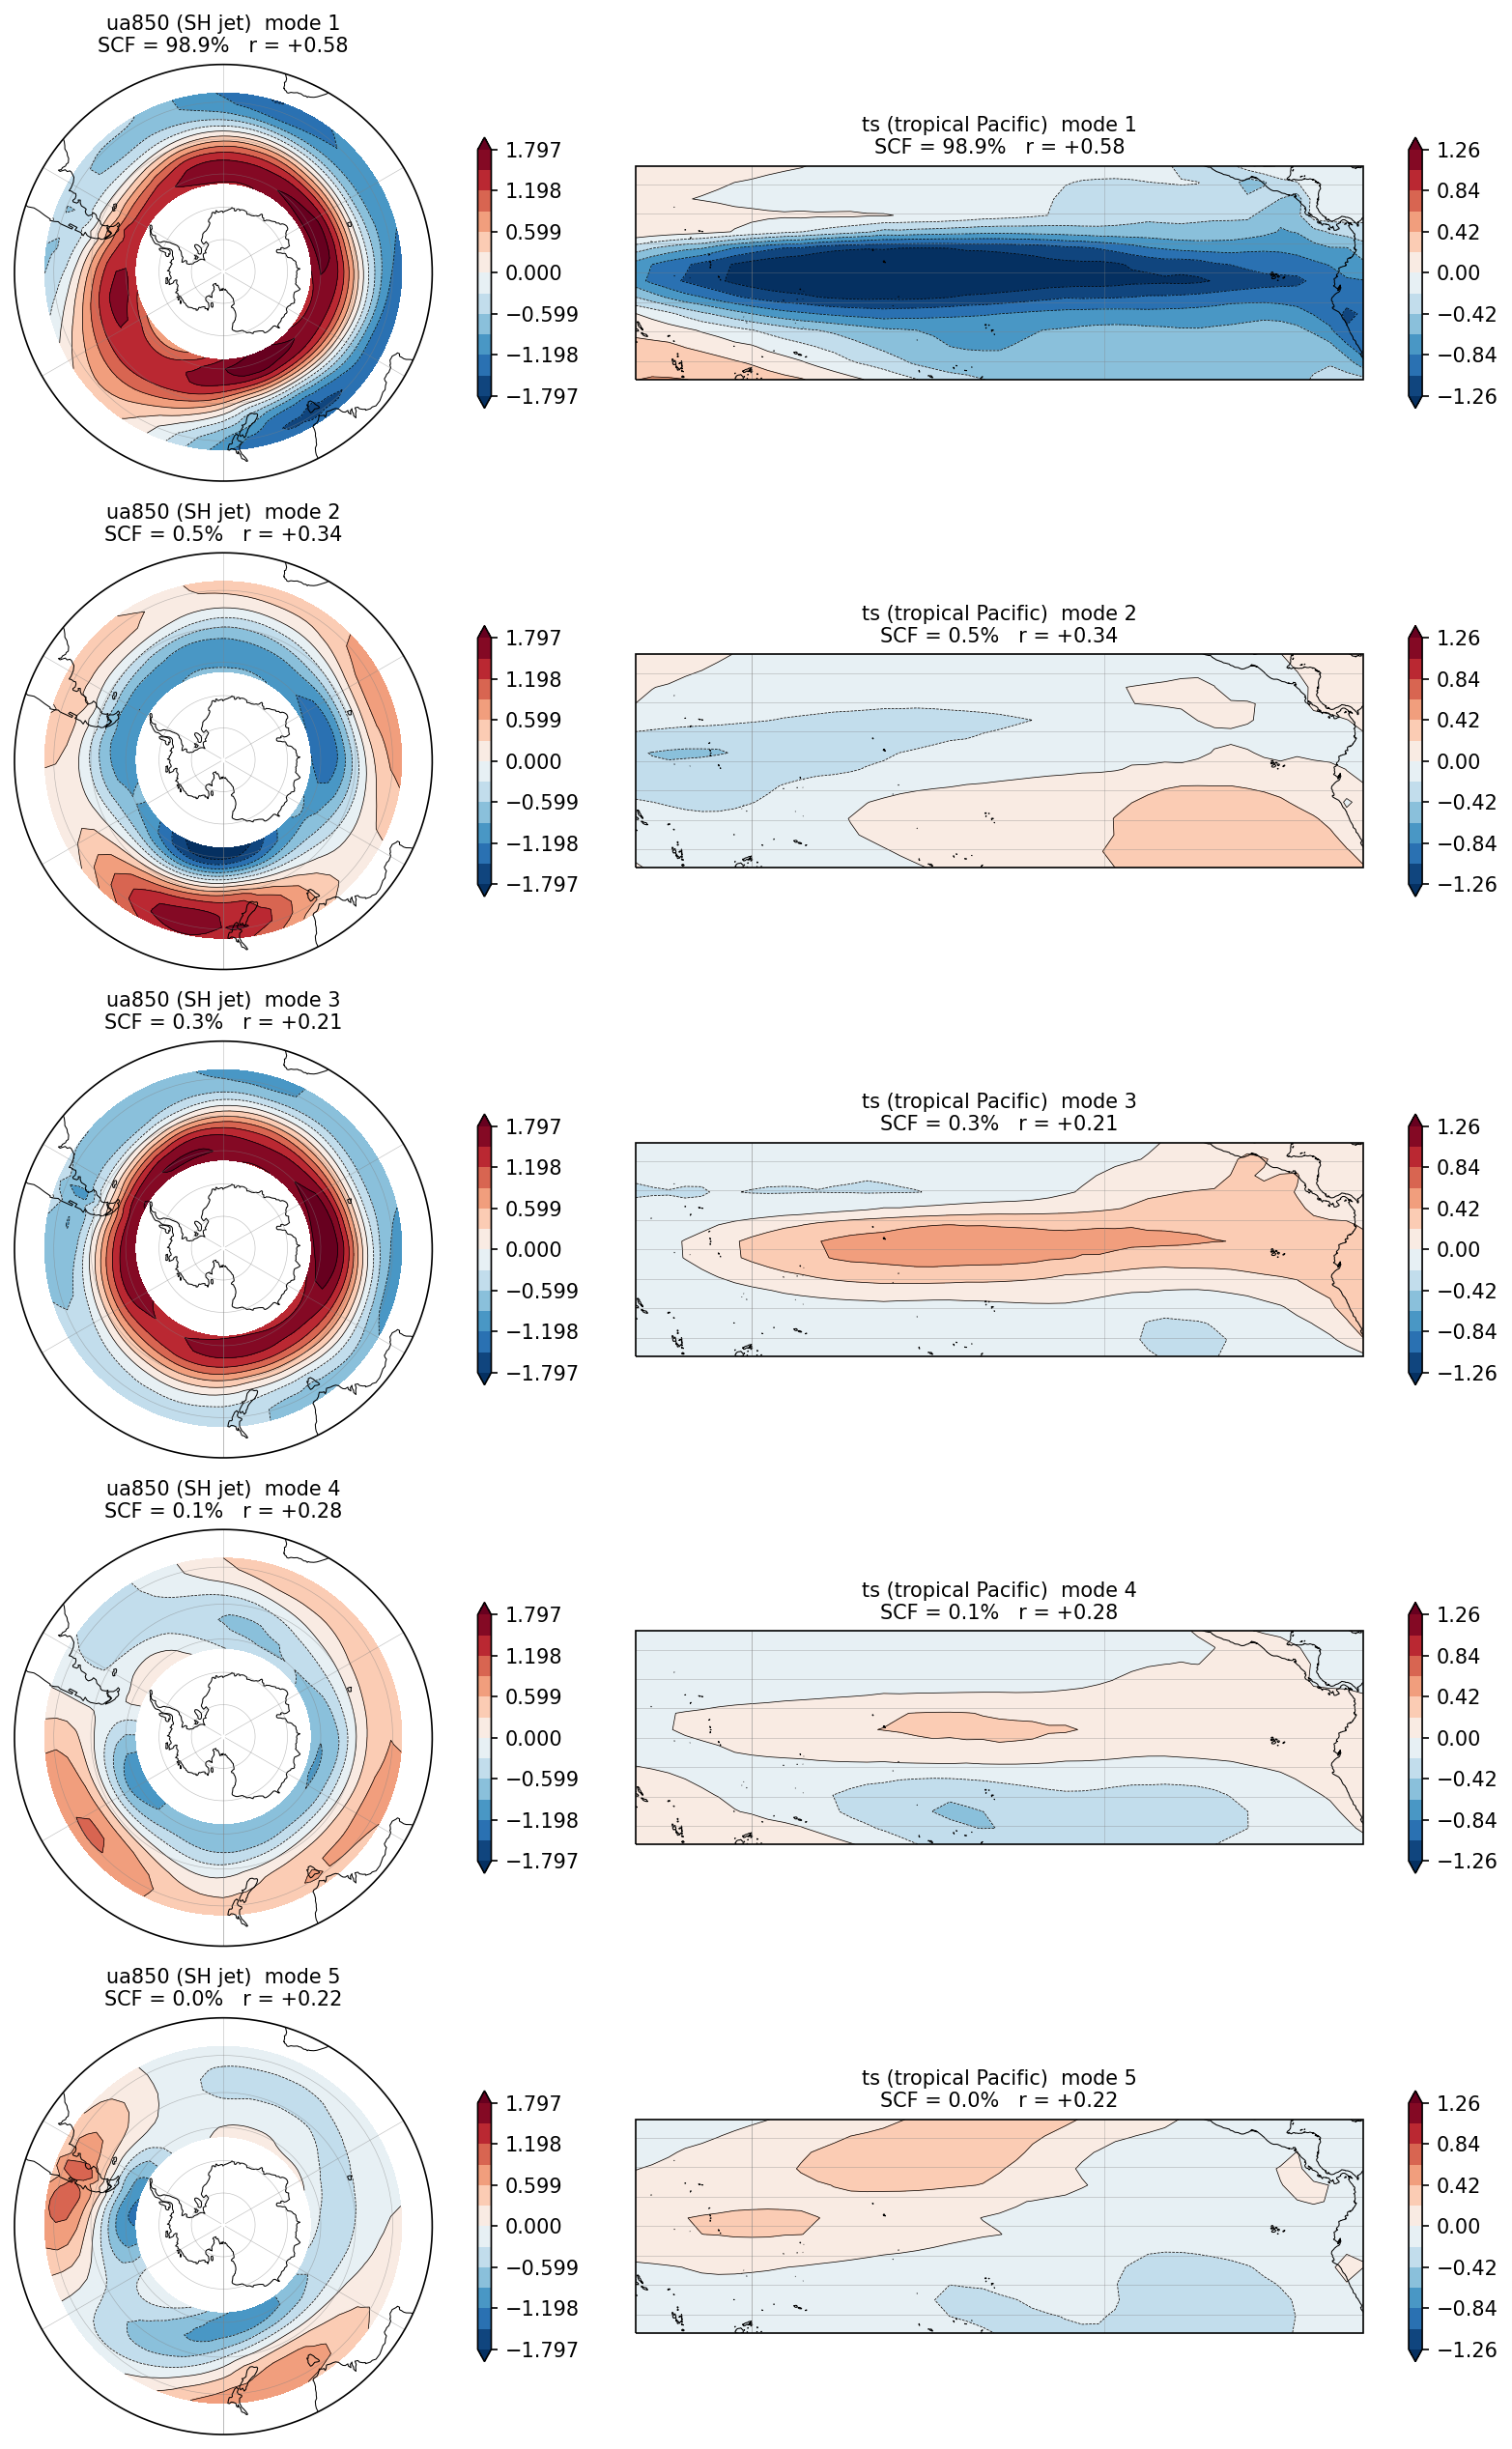

In [8]:
# preprocess data (ts and ua850 are already on 0-360 longitudes, see "Load data")
ts_djf    = djf_mean(lat_band(ts, -20, 20).sel(lon=slice(160, 285)))
ua850_djf = djf_mean(lat_band(ua850, -65, -35))

# apply MCA
res = mca(ua850_djf, ts_djf, n_modes=5)

# print modes and explained variance
for k in range(5):
    print(f'mode {k+1}: SCF={res["scf"][k]*100:5.1f}%   r={res["corr"][k]:+.2f}')

plot_mca(res, n=5);

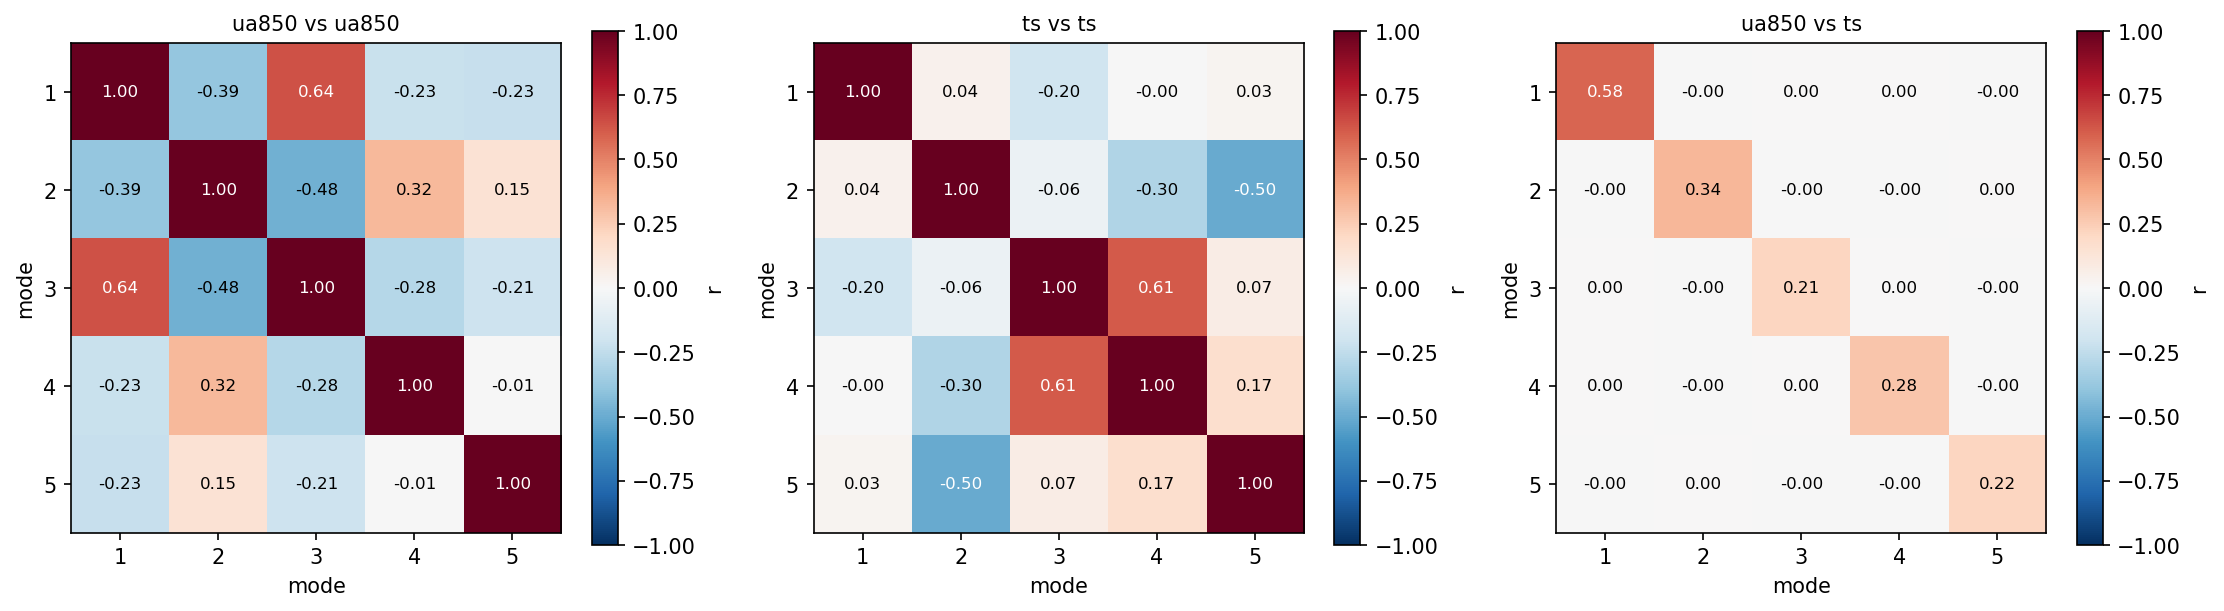

In [9]:
C = plot_coefficient_correlations(res, n=5)

## Clustering and anomalies

/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value

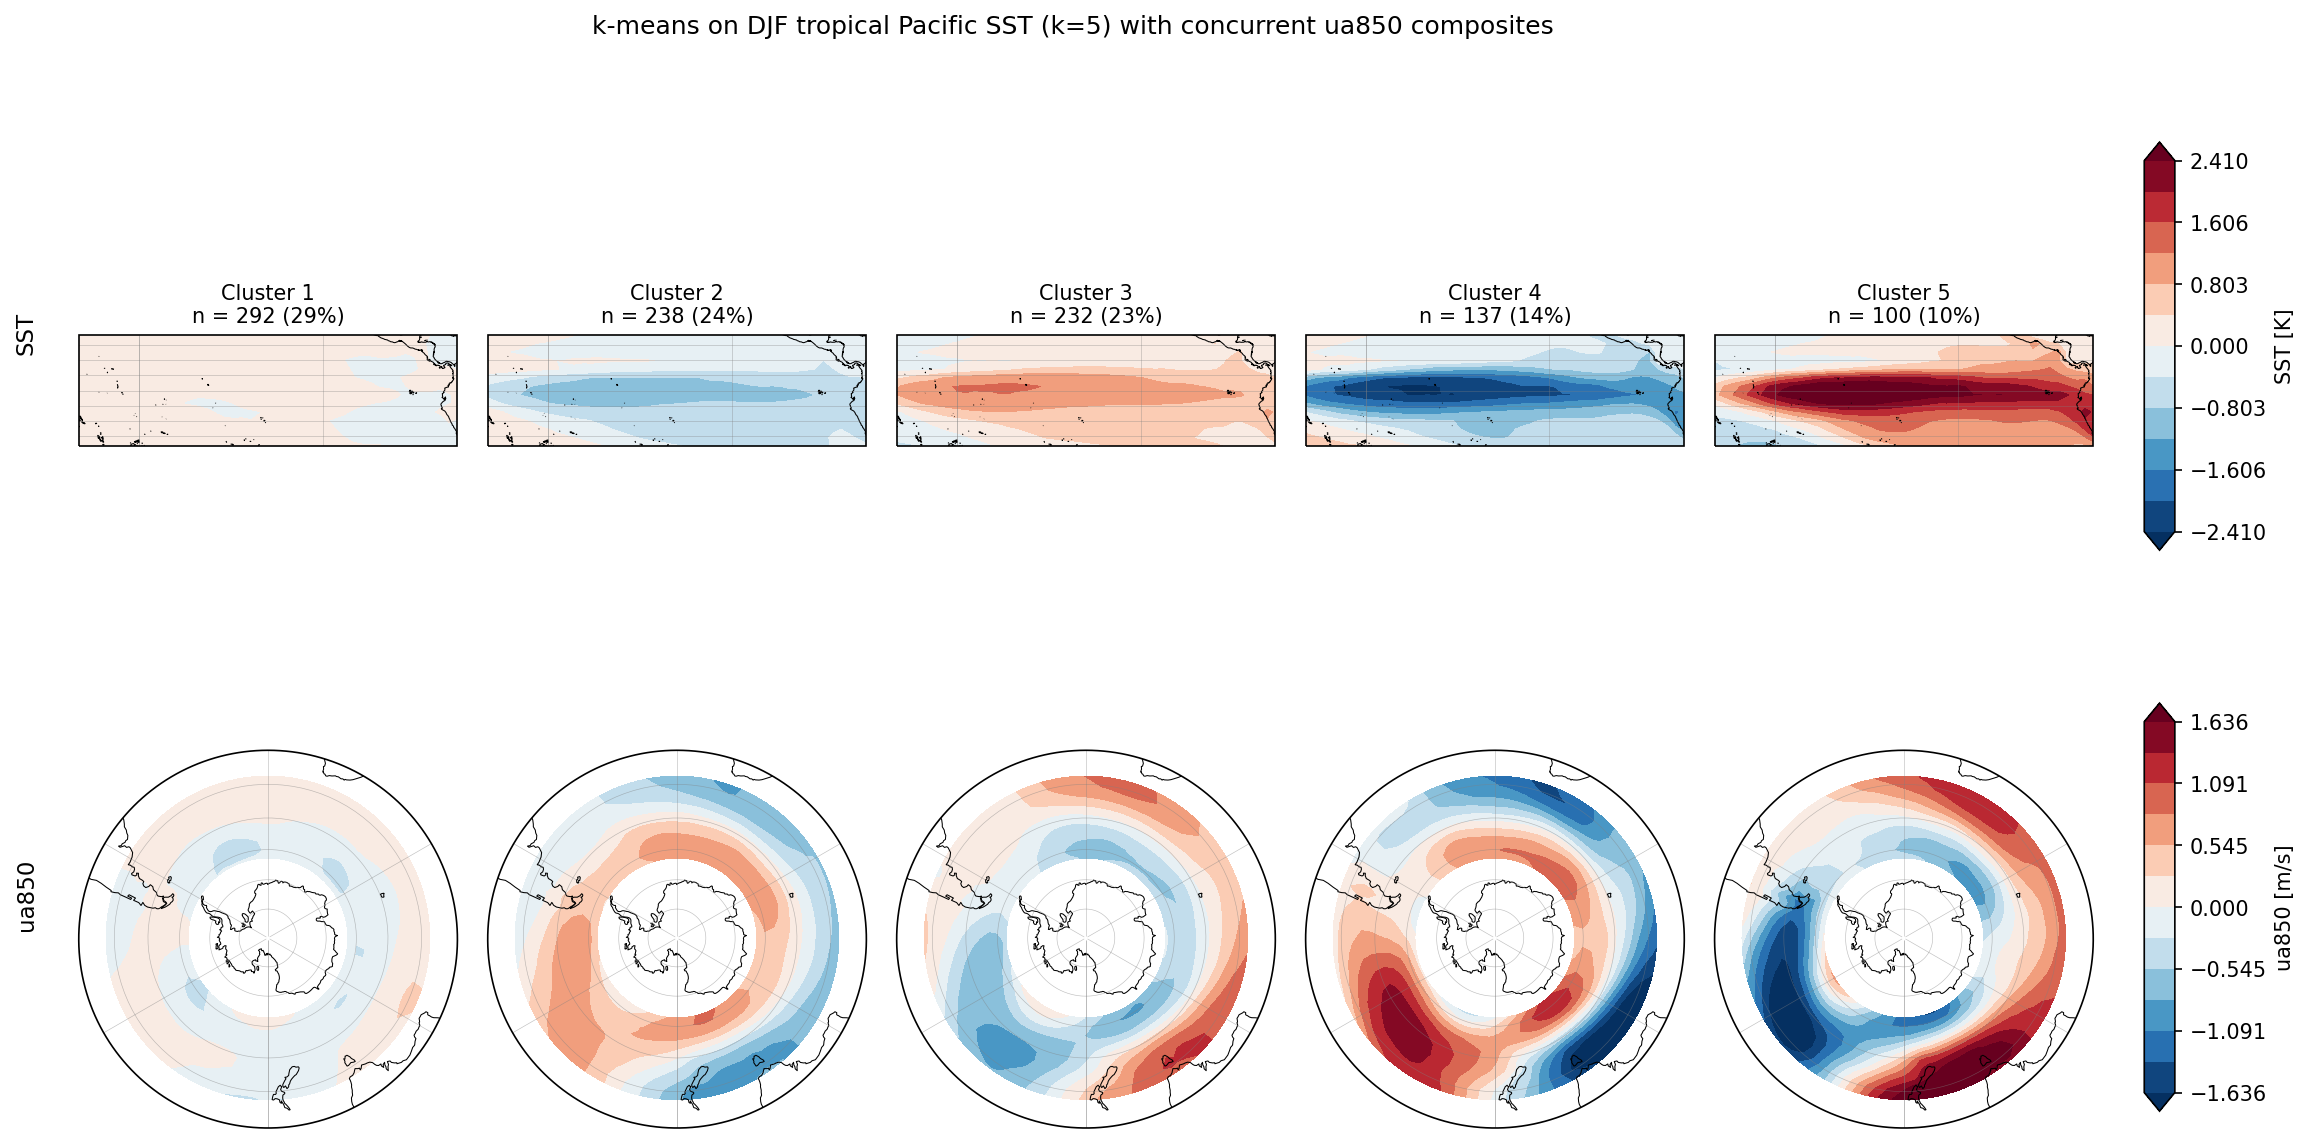

In [22]:
N_CLUSTERS = 5

ts_a, ua_a = xr.align(ts_djf, ua850_djf, join='inner', exclude=['lat', 'lon'])
ts_a = ts_a - ts_a.mean('season_year')
ua_a = ua_a - ua_a.mean('season_year')

# sqrt(cos lat) weighting so the distance metric is area-fair
w = np.sqrt(np.cos(np.deg2rad(ts_a['lat'])).clip(0))
X = (ts_a * w).stack(space=('lat', 'lon')).transpose('season_year', 'space').values
Xc = X[:, ~np.isnan(X).any(axis=0)]

km = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=0).fit(Xc)

# relabel so that cluster 0 is the largest
order = np.argsort(-np.bincount(km.labels_, minlength=N_CLUSTERS))
remap = np.empty(N_CLUSTERS, int)
remap[order] = np.arange(N_CLUSTERS)
labels = xr.DataArray(remap[km.labels_], dims='season_year',
                      coords={'season_year': ts_a['season_year']})

comp_ts = ts_a.groupby(labels.rename('k')).mean('season_year')
comp_ua = ua_a.groupby(labels.rename('k')).mean('season_year')
counts  = np.bincount(labels.values, minlength=N_CLUSTERS)

# no significance test: all-False masks, so nothing is stippled
no_sig_ts = xr.zeros_like(comp_ts, dtype=bool)
no_sig_ua = xr.zeros_like(comp_ua, dtype=bool)

plot_cluster_composites(comp_ts, comp_ua, no_sig_ts, no_sig_ua, counts, len(labels), N_CLUSTERS);

## Composites

35 seasons: [  1  26  78 140 160 202 206 241 338 421 438 487 494 510 529 539 568 591
 618 636 644 658 740 793 801 815 848 860 880 901 904 911 938 956 993]
EP: [2.3  2.09 2.37 2.21 2.65 3.7  2.1  2.36 2.28 3.43 2.15 2.55 2.41 2.25
 2.07 2.85 3.69 2.14 2.19 2.11 2.18 3.23 2.2  2.69 2.82 3.2  2.21 3.21
 2.51 2.55 2.23 2.39 2.64 2.53 2.06]
CP: [2.15 1.92 2.29 1.87 2.43 2.55 1.81 1.74 2.21 2.29 1.68 1.91 1.62 2.03
 2.07 2.39 2.77 1.85 2.12 1.76 1.6  2.37 2.1  2.18 2.5  2.27 1.86 2.47
 2.21 2.31 1.92 1.95 2.13 2.2  1.79]


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWar

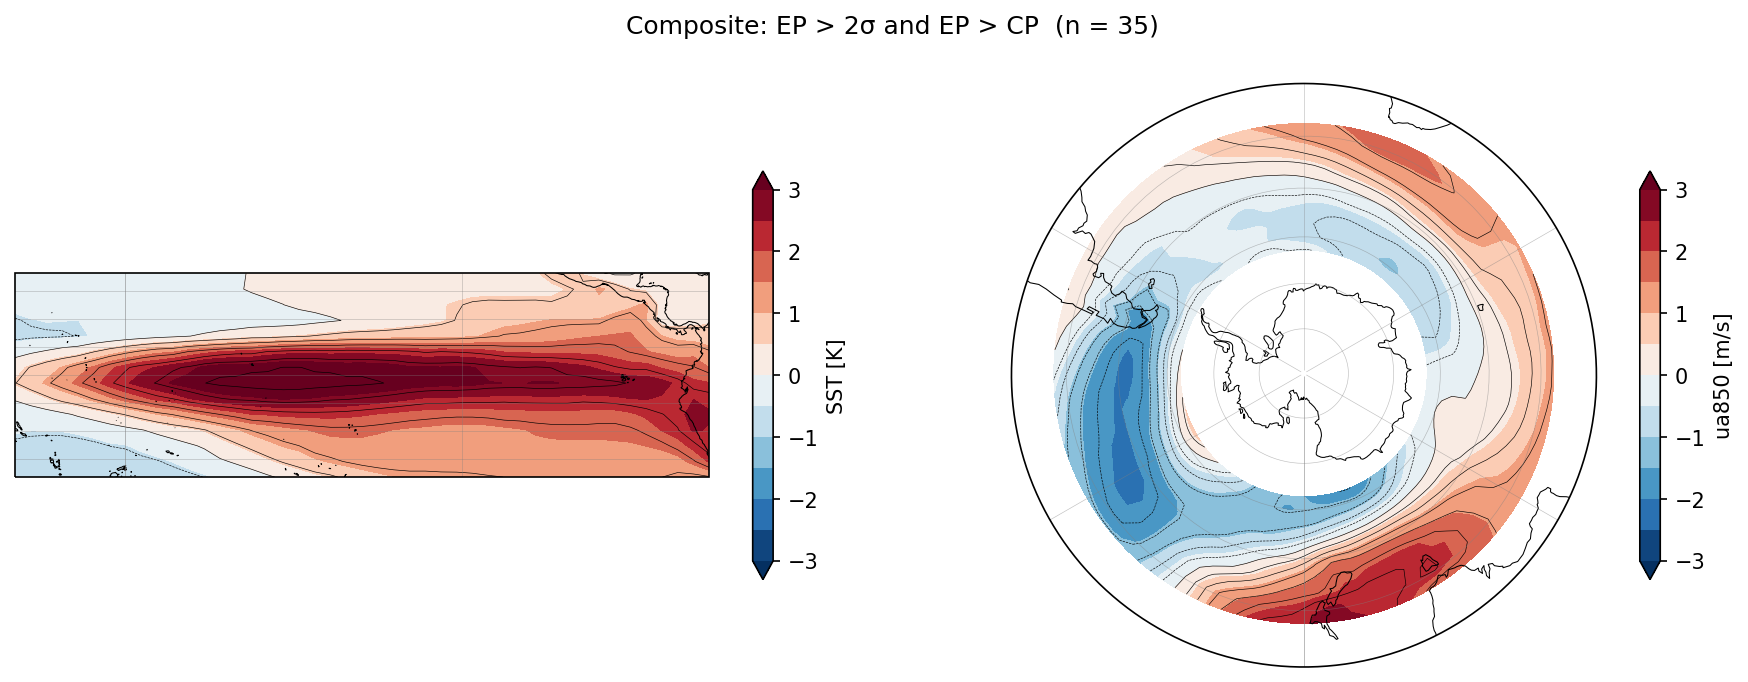

In [18]:
# anomalies over the full record (redefines ts_a / ua_a from the clustering section)
ts_a = ts_djf - ts_djf.mean('season_year')
ua_a = ua850_djf - ua850_djf.mean('season_year')

mask = (ep > 2.0) & (ep > cp)
sel  = mask['season_year'].values[mask.values]
print(f'{len(sel)} seasons:', sel)
print('EP:', np.round(ep.sel(season_year=sel).values, 2))
print('CP:', np.round(cp.sel(season_year=sel).values, 2))

panels = [(ts_a.sel(season_year=sel).mean('season_year'), ccrs.PlateCarree(central_longitude=180), 'SST [K]'),
          (ua_a.sel(season_year=sel).mean('season_year'), ccrs.SouthPolarStereo(), 'ua850 [m/s]')]
# colours: fixed ±3 for both panels (K and m/s); contour lines: 98th percentile of each panel
plot_composite_pair(panels, f'Composite: EP > 2σ and EP > CP  (n = {len(sel)})',
                    fill_levels=np.linspace(-3, 3, 13));

29 seasons: [  7  59 146 195 218 224 295 345 384 457 464 468 520 535 558 561 562 649
 655 687 731 737 755 833 852 871 897 915 975]
EP: [2.3  1.43 1.61 1.83 1.54 1.02 0.7  1.64 1.69 1.41 1.37 1.71 1.81 2.44
 1.53 1.31 1.7  1.56 1.64 1.05 1.82 1.24 1.3  1.88 1.79 1.42 2.12 1.79
 1.89]
CP: [2.3  1.74 1.78 1.92 1.77 1.67 1.54 1.88 2.   1.6  1.62 1.82 2.08 2.47
 1.68 1.58 1.77 1.76 1.86 1.84 2.11 1.56 1.52 1.91 2.02 1.62 2.18 1.84
 1.92]


/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/constructive.py:181: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/fionaspuler/miniforge3/envs/rvae-old/lib/python3.9/site-packages/shapely/predicates.py:798: RuntimeWar

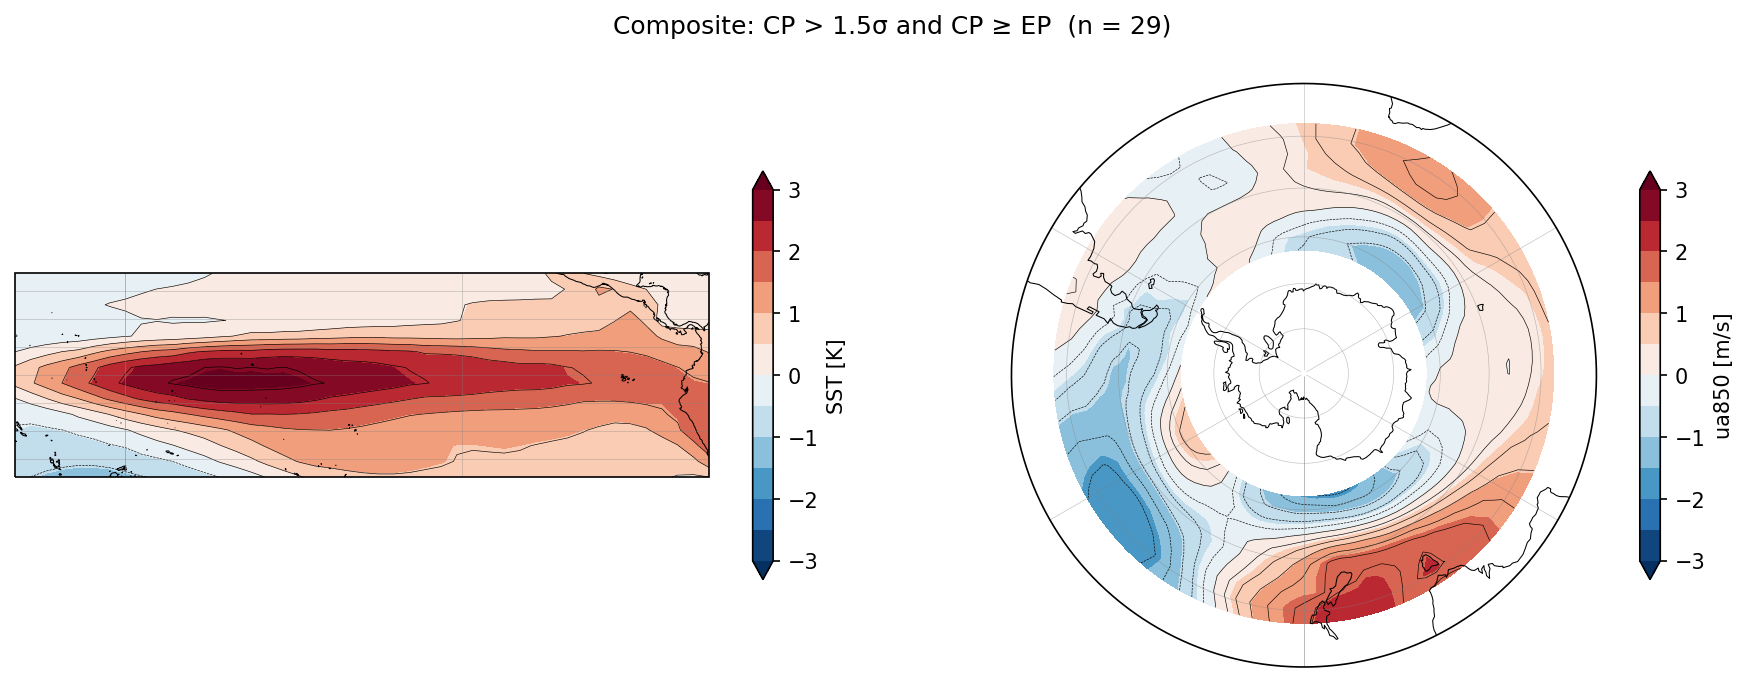

In [20]:
CP_MIN = 1.5
mask = (cp > CP_MIN) & (cp >= ep)
sel  = mask['season_year'].values[mask.values]
print(f'{len(sel)} seasons:', sel)
print('EP:', np.round(ep.sel(season_year=sel).values, 2))
print('CP:', np.round(cp.sel(season_year=sel).values, 2))

panels = [(ts_a.sel(season_year=sel).mean('season_year'), ccrs.PlateCarree(central_longitude=180), 'SST [K]'),
          (ua_a.sel(season_year=sel).mean('season_year'), ccrs.SouthPolarStereo(), 'ua850 [m/s]')]
plot_composite_pair(panels, f'Composite: CP > {CP_MIN}σ and CP ≥ EP  (n = {len(sel)})',
                    fill_levels=np.linspace(-3, 3, 13));